In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch


project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

raw_dir = project_root / "datasets" / "raw"
processed_dir = project_root / "datasets" / "processed"

test_df = pd.read_csv(raw_dir / "test_FD004.txt", sep=r"\s+", header=None)
true_rul_df = pd.read_csv(raw_dir / "RUL_FD004.txt", sep=r"\s+", header=None)

cols = ["engine_id", "cycle", "op1", "op2", "op3"] + [
    f"sensor_{i}" for i in range(1, 22)
]
test_df.columns = cols

with (processed_dir / "output_json.json").open() as file:
    stats_dict = json.load(file)

normalized_rows = []
for _, row in test_df.iterrows():
    first_op = int(abs(round(row["op1"], 0)))
    second_op = abs(round(row["op2"], 2))
    third_op = int(abs(round(row["op3"], 0)))
    cond_key = f"{first_op}_{second_op}_{third_op}"

    norm_row = [row["engine_id"], row["cycle"], row["op1"], row["op2"], row["op3"]]
    for i in range(1, 22):
        value = row[f"sensor_{i}"]
        mean_value = stats_dict[cond_key][f"sensor_{i}_mean"]
        std_value = stats_dict[cond_key][f"sensor_{i}_std"]
        norm_row.append(0.0 if std_value == 0.0 else (value - mean_value) / std_value)

    normalized_rows.append(norm_row)

norm_test_df = pd.DataFrame(normalized_rows, columns=cols)
sequence_length = 30
final_windows = []
final_engine_ids = []

for engine_id, engine_data in norm_test_df.groupby("engine_id", sort=True):
    if len(engine_data) < sequence_length:
        print(f"Engine {engine_id} has fewer than {sequence_length} cycles. Skipping.")
        continue

    final_windows.append(engine_data.iloc[-sequence_length:, 2:].to_numpy())
    final_engine_ids.append(engine_id)

batch_tensor = torch.tensor(np.asarray(final_windows), dtype=torch.float32)
print(f"Batch Tensor Shape: {batch_tensor.shape}")

Engine 10.0 has fewer than 30 cycles. Skipping.
Engine 19.0 has fewer than 30 cycles. Skipping.
Engine 28.0 has fewer than 30 cycles. Skipping.
Engine 125.0 has fewer than 30 cycles. Skipping.
Engine 141.0 has fewer than 30 cycles. Skipping.
Engine 156.0 has fewer than 30 cycles. Skipping.
Engine 164.0 has fewer than 30 cycles. Skipping.
Engine 204.0 has fewer than 30 cycles. Skipping.
Engine 229.0 has fewer than 30 cycles. Skipping.
Engine 239.0 has fewer than 30 cycles. Skipping.
Engine 246.0 has fewer than 30 cycles. Skipping.
Batch Tensor Shape: torch.Size([237, 30, 24])


In [2]:
import sys

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.model import CMAPSSModel

MAX_RUL = 130.0

model = CMAPSSModel(input_size=24, hidden_size=128)
model_path = project_root / "models" / "model.pt"
model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
model.eval()

with torch.no_grad():
    predicted_rul = model(batch_tensor).squeeze(1).numpy()

valid_indices = [int(engine_id) - 1 for engine_id in final_engine_ids]
true_rul_uncapped = true_rul_df.iloc[valid_indices, 0].to_numpy(dtype=np.float32)
true_rul = np.minimum(true_rul_uncapped, MAX_RUL)
results = pd.DataFrame(
    {
        "engine_id": final_engine_ids,
        "predicted_rul": predicted_rul,
        "true_rul_capped": true_rul,
        "true_rul_uncapped": true_rul_uncapped,
        "absolute_error_capped": np.abs(predicted_rul - true_rul),
    }
)

print(results.head())
print(f"Test engines: {len(results)}")
print(f"Evaluation coverage: {len(results)}/{len(true_rul_df)} engines")
print(f"Capped-target MAE at {MAX_RUL:.0f}: {results['absolute_error_capped'].mean():.3f}")

   engine_id  predicted_rul  true_rul_capped  true_rul_uncapped  \
0        1.0      31.645599             22.0               22.0   
1        2.0      34.826855             39.0               39.0   
2        3.0     122.833611            107.0              107.0   
3        4.0      97.798325             75.0               75.0   
4        5.0      93.532074            130.0              149.0   

   absolute_error_capped  
0               9.645599  
1               4.173145  
2              15.833611  
3              22.798325  
4              36.467926  
Test engines: 237
Evaluation coverage: 237/248 engines
Capped-target MAE at 130: 10.731


In [5]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(true_rul, predicted_rul)
rmse = np.sqrt(mse)

print("========================================")
print(f"Evaluation against capped training targets (cap={MAX_RUL:.0f})")
print(f"RMSE: {rmse:.2f} cycles")
print("========================================")

Evaluation against capped training targets (cap=130)
RMSE: 14.83 cycles


Evaluation against capped training targets (primary, cap=130)
MAE: 10.73 cycles
RMSE: 14.83 cycles
R²: 0.887
Median absolute error: 7.54 cycles
90th percentile absolute error: 23.15 cycles
Mean signed error: 0.14 cycles
NASA score: 1059.42 (lower is better)

Evaluation against uncapped FD004 targets (diagnostic only)
MAE: 17.16 cycles
RMSE: 24.16 cycles


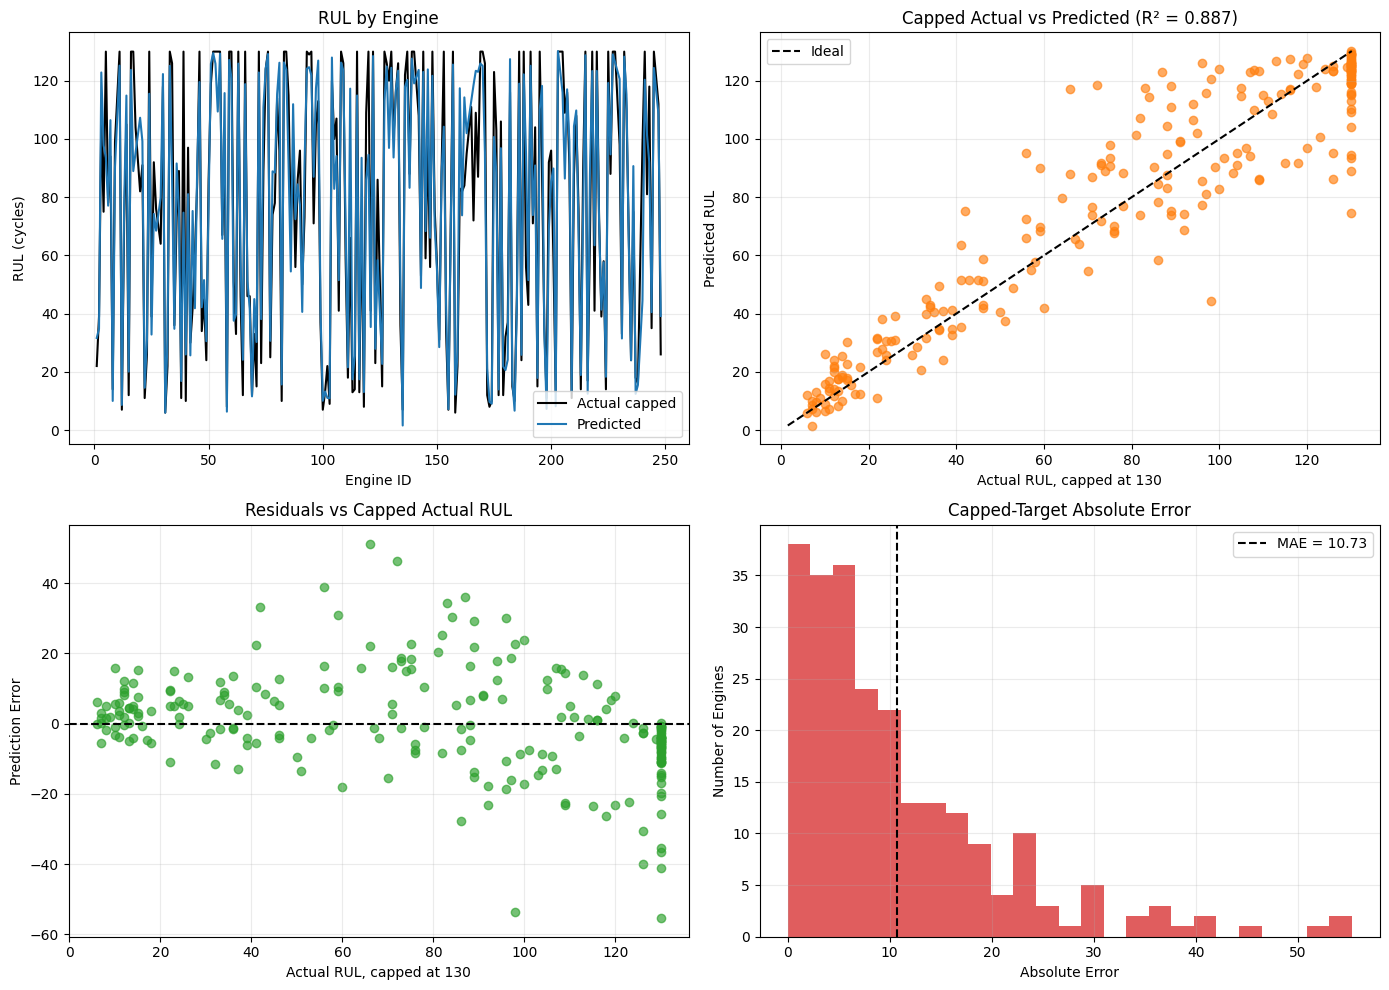

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

comparison = pd.DataFrame(
    {
        "engine_id": final_engine_ids,
        "actual_rul": true_rul,
        "actual_rul_uncapped": true_rul_uncapped,
        "predicted_rul": predicted_rul,
    }
)
comparison["error"] = comparison["predicted_rul"] - comparison["actual_rul"]
comparison["uncapped_error"] = comparison["predicted_rul"] - comparison["actual_rul_uncapped"]
comparison["absolute_error"] = comparison["error"].abs()

# The PHM08 score penalizes late predictions more heavily than early predictions.
def nasa_score(errors):
    errors = np.asarray(errors)
    penalties = np.where(errors < 0, np.exp(-errors / 13.0) - 1, np.exp(errors / 10.0) - 1)
    return float(penalties.sum())

mae = mean_absolute_error(comparison["actual_rul"], comparison["predicted_rul"])
rmse = np.sqrt(mean_squared_error(comparison["actual_rul"], comparison["predicted_rul"]))
r2 = r2_score(comparison["actual_rul"], comparison["predicted_rul"])
uncapped_mae = mean_absolute_error(comparison["actual_rul_uncapped"], comparison["predicted_rul"])
uncapped_rmse = np.sqrt(mean_squared_error(comparison["actual_rul_uncapped"], comparison["predicted_rul"]))

print(f"Evaluation against capped training targets (primary, cap={MAX_RUL:.0f})")
print(f"MAE: {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²: {r2:.3f}")
print(f"Median absolute error: {comparison['absolute_error'].median():.2f} cycles")
print(f"90th percentile absolute error: {comparison['absolute_error'].quantile(0.90):.2f} cycles")
print(f"Mean signed error: {comparison['error'].mean():.2f} cycles")
print(f"NASA score: {nasa_score(comparison['error']):.2f} (lower is better)")
print("\nEvaluation against uncapped FD004 targets (diagnostic only)")
print(f"MAE: {uncapped_mae:.2f} cycles")
print(f"RMSE: {uncapped_rmse:.2f} cycles")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(comparison["engine_id"], comparison["actual_rul"], label="Actual capped", color="black")
axes[0, 0].plot(comparison["engine_id"], comparison["predicted_rul"], label="Predicted", color="tab:blue")
axes[0, 0].set_title("RUL by Engine")
axes[0, 0].set_xlabel("Engine ID")
axes[0, 0].set_ylabel("RUL (cycles)")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].scatter(comparison["actual_rul"], comparison["predicted_rul"], alpha=0.65, color="tab:orange")
axis_min = min(comparison["actual_rul"].min(), comparison["predicted_rul"].min())
axis_max = max(comparison["actual_rul"].max(), comparison["predicted_rul"].max())
axes[0, 1].plot([axis_min, axis_max], [axis_min, axis_max], "k--", label="Ideal")
axes[0, 1].set_title(f"Capped Actual vs Predicted (R² = {r2:.3f})")
axes[0, 1].set_xlabel(f"Actual RUL, capped at {MAX_RUL:.0f}")
axes[0, 1].set_ylabel("Predicted RUL")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

axes[1, 0].scatter(comparison["actual_rul"], comparison["error"], alpha=0.65, color="tab:green")
axes[1, 0].axhline(0, color="black", linestyle="--")
axes[1, 0].set_title("Residuals vs Capped Actual RUL")
axes[1, 0].set_xlabel(f"Actual RUL, capped at {MAX_RUL:.0f}")
axes[1, 0].set_ylabel("Prediction Error")
axes[1, 0].grid(alpha=0.25)

axes[1, 1].hist(comparison["absolute_error"], bins=25, color="tab:red", alpha=0.75)
axes[1, 1].axvline(mae, color="black", linestyle="--", label=f"MAE = {mae:.2f}")
axes[1, 1].set_title("Capped-Target Absolute Error")
axes[1, 1].set_xlabel("Absolute Error")
axes[1, 1].set_ylabel("Number of Engines")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [7]:
condition_rows = []
for engine_id in final_engine_ids:
    engine_rows = test_df[test_df["engine_id"] == engine_id]
    last_row = engine_rows.iloc[-1]
    condition_rows.append(
        f"{int(abs(round(last_row['op1'], 0)))}_"
        f"{abs(round(last_row['op2'], 2))}_"
        f"{int(abs(round(last_row['op3'], 0)))}"
    )

comparison["condition"] = condition_rows
condition_summary = (
    comparison.groupby("condition")
    .apply(
        lambda group: pd.Series(
            {
                "engines": len(group),
                "MAE": mean_absolute_error(group["actual_rul"], group["predicted_rul"]),
                "RMSE": np.sqrt(mean_squared_error(group["actual_rul"], group["predicted_rul"])),
                "NASA_score": nasa_score(group["error"]),
                "mean_error": group["error"].mean(),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

print("\nPerformance by operating condition")
display(condition_summary.round(2))


Performance by operating condition


,condition,engines,MAE,RMSE,NASA_score,mean_error
0,0_0.0_100,29.0,12.65,18.48,290.59,-1.10
1,10_0.25_100,32.0,12.60,16.23,114.12,-4.08
2,20_0.7_100,37.0,9.74,12.66,113.07,2.89
3,25_0.62_60,43.0,8.84,13.34,134.43,-1.38
4,35_0.84_100,35.0,10.65,14.77,180.23,1.57
5,42_0.84_100,61.0,10.82,14.38,226.98,1.51
